## 1. Load the results of generated adversarial examples

### Our Methods

In [1]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt

parameter_grid_baseline = {
    '_lambda': [1], # Regularization parameter, 0.01, 0.03, 0.1, 0.3, 0.5, 0.7, 1 # 0.6, 0.7, 0.8, 0.9, 1
    'optimizer': ['adam'],  # Using Adam optimizer
    'lr': [0.1],  # Learning rates to try, 0.01, 0.03, 0.1, 0.15, 0.2, 0.25, 0.3
    'max_iter': [300],  # Maximum iterations to try
    'sample_num': [500],  # Number of samples to generate
    'kappa': [0],  # Kappa value
}

dataset_list = ['adult', 'phishing_url', 'pendigit', 'german', 'german_credit', 'electricity', 'covertype', ]
model_list = ['MLP', 'SoftDecisionTree', 'TabTransformer']

folder_path = 'results'
attack_name = ['baseline', 'pgd', 'deltaz']
sample_times = [500, 497, 149, 153]
file_name = 'overall_results.json'



In [2]:
df_list = []
for attack_name in attack_name:
    for data_name in dataset_list:
        for model_name in model_list:
            for sample_time in sample_times:
                output_path = f'{folder_path}/{data_name}/{model_name}/{attack_name}/Try_{sample_time}_inputs'
                file_path = os.path.join(output_path, file_name)
                
                try:
                    with open(file_path, 'r') as file:
                        data = json.load(file)

                    # Flatten the JSON structure and convert it into a DataFrame
                    df = pd.json_normalize(data)
                    df.index = range(1, len(df) + 1)
                    df.index.name = 'Search'
                    df['attack'] = attack_name
                    df['dataset'] = data_name
                    df['model'] = model_name
                    df_list.append(df)
                except FileNotFoundError:
                    # print(f"Skipping missing file: {file_path}")
                    continue

if df_list:  # Only proceed if we have data
    df = pd.concat(df_list)
    df.reset_index(drop=True, inplace=True)
    # export the DataFrame to a CSV file
    output_file = f'results/overall_results.csv'
    df.to_csv(output_file)
else:
    print("No data files were found to process")

In [3]:
df['metrics.idsr'] = df['metrics.success_rate'] * (1 - df['metrics.outlier_rate'])


In [4]:
# select rows based on params._lambda, params.lr
df_baseline = df[(df['params._lambda'] == 1) & (df['params.lr'] == 0.1) & (df['attack'] == 'baseline')]
df_baseline[['dataset', 'model', 'attack', 'metrics.success_rate', 'metrics.outliers', 'metrics.outlier_rate', 'metrics.idsr']].drop_duplicates()

,dataset,model,attack,metrics.success_rate,metrics.outliers,metrics.outlier_rate,metrics.idsr
37,adult,MLP,baseline,0.510000,42/255,0.164706,0.426000
42,adult,SoftDecisionTree,baseline,0.494000,28/247,0.113360,0.438000
43,adult,TabTransformer,baseline,0.290000,13/145,0.089655,0.264000
44,phishing_url,MLP,baseline,0.980000,87/490,0.177551,0.806000
45,phishing_url,SoftDecisionTree,baseline,0.744000,30/372,0.080645,0.684000
46,phishing_url,TabTransformer,baseline,0.970000,82/485,0.169072,0.806000
47,pendigit,MLP,baseline,0.908000,25/454,0.055066,0.858000
48,pendigit,SoftDecisionTree,baseline,0.538000,12/269,0.044610,0.514000
49,pendigit,TabTransformer,baseline,0.974000,42/487,0.086242,0.890000
50,german_credit,MLP,baseline,0.093960,0/14,0.000000,0.093960


In [5]:
# select rows based on params._lambda, params.lr
df_pgd = df[(df['attack'] == 'pgd') & (df['params.epsilon'] == 0.5) & (df['params.alpha'] == 0.05) & (df['params.num_steps'] == 50)]
df_pgd[['dataset', 'model', 'attack', 'metrics.success_rate', 'metrics.outliers', 'metrics.outlier_rate', 'metrics.idsr']].drop_duplicates()

,dataset,model,attack,metrics.success_rate,metrics.outliers,metrics.outlier_rate,metrics.idsr
115,adult,MLP,pgd,0.592000,235/296,0.793919,0.122000
121,adult,SoftDecisionTree,pgd,0.576000,212/288,0.736111,0.152000
122,adult,TabTransformer,pgd,0.428000,109/214,0.509346,0.210000
123,phishing_url,MLP,pgd,0.930000,360/465,0.774194,0.210000
124,phishing_url,SoftDecisionTree,pgd,0.928000,339/464,0.730603,0.250000
125,phishing_url,TabTransformer,pgd,0.902000,291/451,0.645233,0.320000
126,pendigit,MLP,pgd,0.660000,21/330,0.063636,0.618000
127,pendigit,SoftDecisionTree,pgd,0.744000,19/372,0.051075,0.706000
128,pendigit,TabTransformer,pgd,0.696000,20/348,0.057471,0.656000
129,german_credit,MLP,pgd,0.181208,2/27,0.074074,0.167785


In [6]:
# select rows based on params._lambda, params.lr
df_deltaz = df[(df['attack'] == 'deltaz') & (df['params._lambda'] == 1) & (df['params.lr'] == 0.1) & (df['params.p_norm'] == 2)]
df_deltaz[['dataset', 'model', 'attack', 'metrics.success_rate', 'metrics.outliers', 'metrics.outlier_rate', 'metrics.idsr']].drop_duplicates()

,dataset,model,attack,metrics.success_rate,metrics.outliers,metrics.outlier_rate,metrics.idsr
199,adult,MLP,deltaz,0.734000,117/367,0.318801,0.500000
208,adult,SoftDecisionTree,deltaz,0.532000,27/266,0.101504,0.478000
209,adult,TabTransformer,deltaz,0.038000,0/19,0.000000,0.038000
210,phishing_url,MLP,deltaz,0.826000,15/413,0.036320,0.796000
211,phishing_url,SoftDecisionTree,deltaz,0.658000,7/329,0.021277,0.644000
212,phishing_url,TabTransformer,deltaz,0.858000,19/429,0.044289,0.820000
213,german_credit,MLP,deltaz,0.080537,0/12,0.000000,0.080537
214,german_credit,SoftDecisionTree,deltaz,0.065359,0/10,0.000000,0.065359
215,german_credit,TabTransformer,deltaz,0.107383,1/16,0.062500,0.100671
216,electricity,MLP,deltaz,0.658000,6/329,0.018237,0.646000


In [7]:
df_combined = pd.concat([df_baseline, df_pgd, df_deltaz])
df_combined[['dataset', 'model', 'attack', 'metrics.success_rate', 'metrics.outliers', 
             'metrics.outlier_rate', 'metrics.idsr']].drop_duplicates().to_csv('results/overall_results_task3.csv')


In [ ]:
parameter_grid_search = {
    '_lambda': [0.5, 0.6, 0.7, 0.8, 0.9, 1], # Regularization parameter, # 0.6, 0.7, 0.8, 0.9, 1
    'optimizer': ['adam'],  # Using Adam optimizer
    'lr': [0.01, 0.03, 0.1, 0.15, 0.2, 0.25, 0.3],  # Learning rates to try
    'max_iter': [300],  # Maximum iterations to try
    'sample_num': [500],  # Number of samples to generate
    'kappa': [0],  # Kappa value
}

dataset = 'adult'
model = 'MLP'
attack_name = 'VAEAttack'
sample_times = 500
file_name = 'overall_results.json'

output_path = f'{folder_path}/{dataset}/{model}/{attack_name}/Try_{sample_times}_inputs'
file_path = os.path.join(output_path, file_name)

with open(file_path, 'r') as file:
    data = json.load(file)

# Flatten the JSON structure and convert it into a DataFrame
df = pd.json_normalize(data)


In [9]:
df[['params._lambda', 'params.lr', 'metrics.success_rate', 'metrics.mean_l2_distance']]

,params._lambda,params.lr,metrics.success_rate,metrics.mean_l2_distance
0,0.5,0.01,0.212000,0.202274
1,0.5,0.03,0.268000,0.219553
2,0.5,0.10,0.366000,0.293129
3,0.5,0.15,0.434000,0.322796
4,0.5,0.20,0.492000,0.384044
...,...,...,...,...
214,1.0,0.10,0.065359,0.008226
215,1.0,0.10,0.107383,0.015610
216,1.0,0.10,0.658000,0.803456
217,1.0,0.10,0.662000,0.844194


In [10]:
# sort the dataframe by success rate descending
df_sort_by_asr = df.sort_values(by='metrics.success_rate', ascending=False)
candidature = df_sort_by_asr
candidature


,params._lambda,params.optimizer,params.lr,params.max_iter,params.sample_num,params.kappa,metrics.success_rate,metrics.mean_l2_distance,metrics.mean_linf_distance,metrics.perturbed_features_latent,...,metrics.outlier_rate,metrics.outliers,attack,dataset,model,params.epsilon,params.alpha,params.num_steps,params.p_norm,metrics.idsr
60,1.0,adam,0.10,300.0,500,0.0,0.98994,0.473002,0.270460,11.707317,...,0.266260,131/492,baseline,covertype,TabTransformer,NaN,NaN,NaN,NaN,0.726358
44,1.0,adam,0.10,300.0,500,0.0,0.98000,0.913237,0.493863,15.738776,...,0.177551,87/490,baseline,phishing_url,MLP,NaN,NaN,NaN,NaN,0.806000
49,1.0,adam,0.10,300.0,500,0.0,0.97400,1.085042,0.686727,8.000000,...,0.086242,42/487,baseline,pendigit,TabTransformer,NaN,NaN,NaN,NaN,0.890000
46,1.0,adam,0.10,300.0,500,0.0,0.97000,0.873912,0.478200,15.538144,...,0.169072,82/485,baseline,phishing_url,TabTransformer,NaN,NaN,NaN,NaN,0.806000
123,NaN,NaN,NaN,NaN,500,NaN,0.93000,1.722151,0.500000,15.888172,...,0.774194,360/465,pgd,phishing_url,MLP,0.5,0.05,50.0,NaN,0.210000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,1.0,NaN,0.10,300.0,500,NaN,0.05000,0.088149,0.043908,16.000000,...,0.160000,4/25,deltaz,adult,MLP,NaN,NaN,NaN,1.0,0.042000
194,1.0,NaN,0.01,300.0,500,NaN,0.05000,0.008192,0.004832,16.000000,...,0.200000,5/25,deltaz,adult,MLP,NaN,NaN,NaN,1.0,0.040000
166,0.8,NaN,0.01,300.0,500,NaN,0.05000,0.009914,0.006082,16.000000,...,0.200000,5/25,deltaz,adult,MLP,NaN,NaN,NaN,1.0,0.040000
182,0.9,NaN,0.03,300.0,500,NaN,0.04800,0.030522,0.018123,16.000000,...,0.208333,5/24,deltaz,adult,MLP,NaN,NaN,NaN,1.0,0.038000


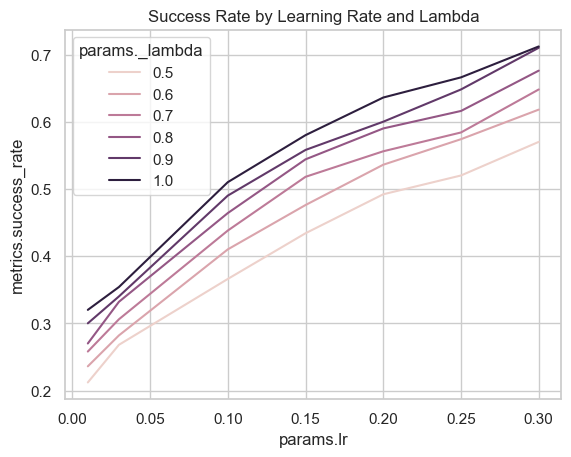

In [10]:
# plot line chart for success rate (y) by different learning rate (x) with different lambda (hue)
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook")
g = sns.lineplot(data=candidature, x='params.lr', y='metrics.success_rate', hue='params._lambda', 
                 markers=True, dashes=False)
g.set(title="Success Rate by Learning Rate and Lambda")
plt.show()


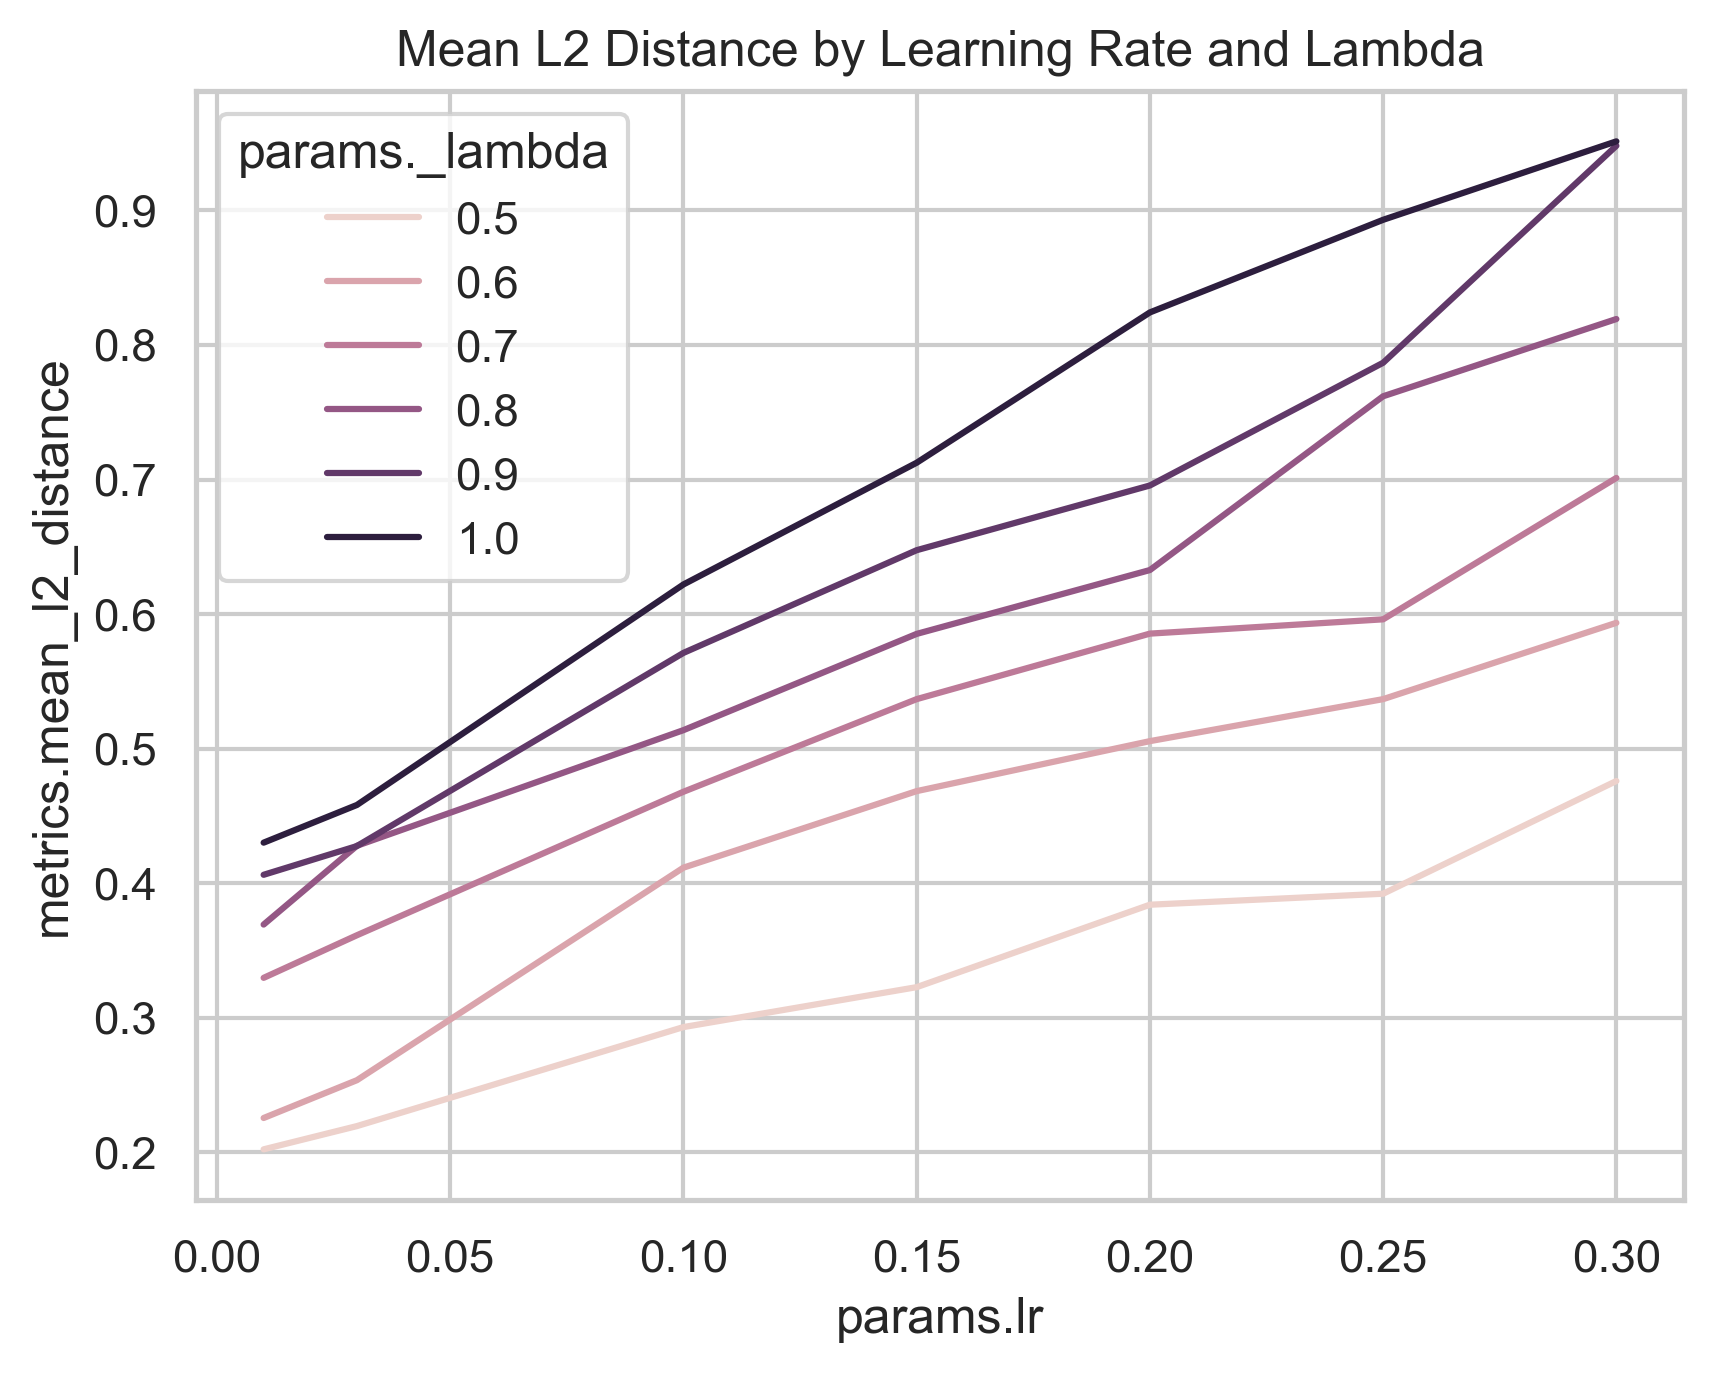

In [129]:

# plot line chart for success rate (y) by different learning rate (x) with different lambda (hue)
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook")
g = sns.lineplot(data=candidature, x='params.lr', y='metrics.mean_l2_distance', hue='params._lambda', 
                 markers=True, dashes=False)
g.set(title="Mean L2 Distance by Learning Rate and Lambda")
plt.show()


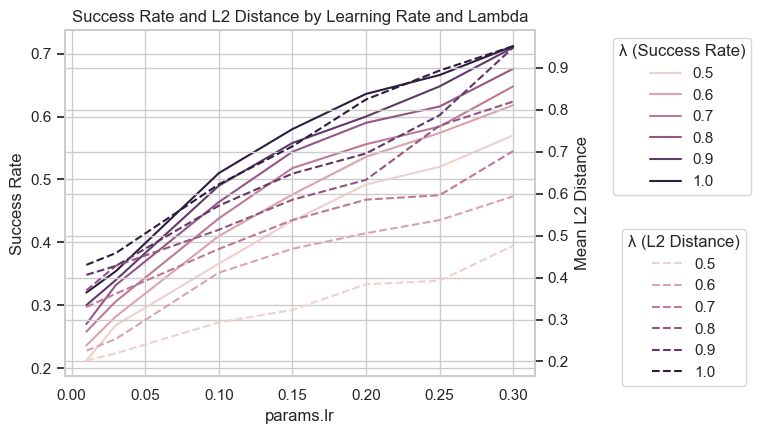

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style and context for seaborn
sns.set_style("whitegrid")
sns.set_context("notebook")

# Create a figure with one subplot
fig, ax = plt.subplots(figsize=(8, 4.5))

# Plot both line charts on the same x-axis
line1 = sns.lineplot(data=candidature, x='params.lr', y='metrics.success_rate', hue='params._lambda',
             markers=True, dashes=False, ax=ax)
ax.set_ylabel('Success Rate')

# Create a second y-axis
ax2 = ax.twinx()
line2 = sns.lineplot(data=candidature, x='params.lr', y='metrics.mean_l2_distance', hue='params._lambda',
             markers=True, dashes=False, ax=ax2, linestyle='--')
ax2.set_ylabel('Mean L2 Distance')

# Move legends outside to the right
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1, labels1, bbox_to_anchor=(1.15, 1), loc='upper left', title='λ (Success Rate)')
ax2.legend(lines2, labels2, bbox_to_anchor=(1.17, -0.05), loc='lower left', title='λ (L2 Distance)')

# Set title and adjust layout
ax.set_title("Success Rate and L2 Distance by Learning Rate and Lambda")
plt.tight_layout()

# Show the figure
plt.show()

/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_35705/45521743.py:12: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  line1 = sns.lineplot(


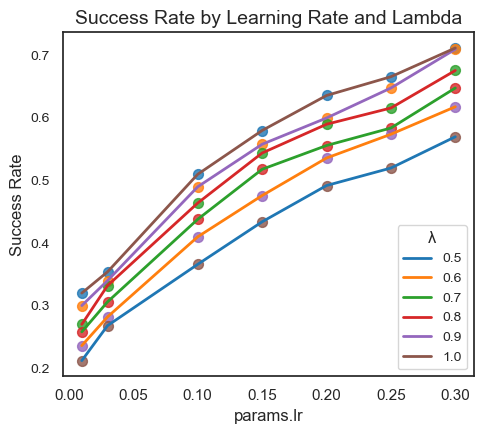

/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_35705/45521743.py:39: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  line2 = sns.lineplot(


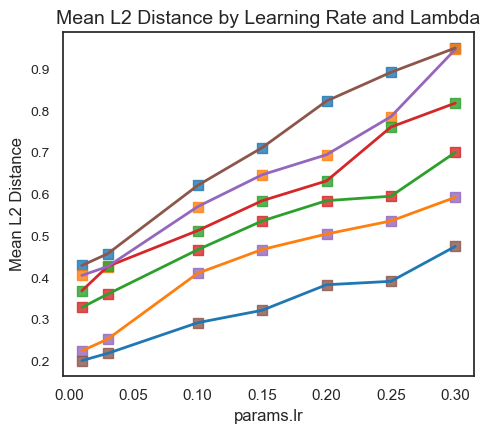

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for seaborn
sns.set_style("white")  # Removes the grid

# Create first figure for Success Rate
plt.figure(figsize=(5, 4.5))
palette = sns.color_palette("tab10")

# Plot Success Rate
line1 = sns.lineplot(
    data=candidature, x='params.lr', y='metrics.success_rate', hue='params._lambda',
    palette=palette, markers=True, dashes=False, linewidth=2, markersize=8
)
plt.ylabel('Success Rate', fontsize=12)
plt.tick_params(axis='y', labelsize=10)

# Add points to success rate plot using same colors as lines
for line, lambda_val in zip(line1.get_lines(), candidature['params._lambda'].unique()):
    color = line.get_color()
    subset = candidature[candidature['params._lambda'] == lambda_val]
    plt.scatter(subset['params.lr'], subset['metrics.success_rate'], 
               color=color, s=50, alpha=0.8)

# Customize legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, loc='lower right', title='λ', fontsize=10)
plt.title("Success Rate by Learning Rate and Lambda", fontsize=14)

# Adjust layout and show
plt.tight_layout()
plt.show()

# Create second figure for L2 Distance
plt.figure(figsize=(5, 4.5))

# Plot L2 Distance
line2 = sns.lineplot(
    data=candidature, x='params.lr', y='metrics.mean_l2_distance', hue='params._lambda',
    palette=palette, markers=True, dashes=True, linewidth=2, markersize=8
)
plt.ylabel('Mean L2 Distance', fontsize=12)
plt.tick_params(axis='y', labelsize=10)

# Add points to L2 distance plot using same colors as lines
for line, lambda_val in zip(line2.get_lines(), candidature['params._lambda'].unique()):
    color = line.get_color()
    subset = candidature[candidature['params._lambda'] == lambda_val]
    plt.scatter(subset['params.lr'], subset['metrics.mean_l2_distance'], 
                color=color, s=50, alpha=0.8, marker='s')

# Remove legend from second plot
plt.gca().get_legend().remove()
plt.title("Mean L2 Distance by Learning Rate and Lambda", fontsize=14)

# Adjust layout and show
plt.tight_layout()
plt.show()


In [13]:
# sort candidature by l2 distance ascending
# select 'params.max_iter' == 300
candidature[candidature['params.max_iter'] == 300].sort_values(by='metrics.mean_l2_distance')

,params._lambda,params.optimizer,params.lr,params.max_iter,params.sample_num,params.kappa,metrics.success_rate,metrics.mean_l2_distance,metrics.mean_linf_distance,metrics.perturbed_features_latent,metrics.perturbed_features_input,metrics.mean_confidence_successful,metrics.mean_confidence_unsuccessful,metrics.min_confidence_unsuccessful,metrics.max_confidence_unsuccessful,metrics.mean_md_distance,metrics.outlier_rate,metrics.outliers
0,0.5,adam,0.01,300,500,0,0.212,0.202274,0.101374,12.226415,4.245283,0.548000,0.171002,0.0,0.495507,3.509036,0.000000,0/500
1,0.5,adam,0.03,300,500,0,0.268,0.219553,0.113221,13.007463,4.223881,0.540250,0.171125,0.0,0.498684,3.423468,0.000000,0/500
7,0.6,adam,0.01,300,500,0,0.236,0.225566,0.115164,12.610169,4.228814,0.544838,0.172346,0.0,0.497659,3.472723,0.000000,0/500
8,0.6,adam,0.03,300,500,0,0.282,0.253668,0.131572,13.148936,4.234043,0.538363,0.176125,0.0,0.498684,3.495735,0.000000,0/500
2,0.5,adam,0.10,300,500,0,0.366,0.293129,0.148903,13.797814,4.459016,0.547018,0.179308,0.0,0.494513,3.597238,0.000000,0/500
3,0.5,adam,0.15,300,500,0,0.434,0.322796,0.160735,14.152074,4.608295,0.574315,0.184530,0.0,0.497200,3.682592,0.000000,0/500
14,0.7,adam,0.01,300,500,0,0.258,0.329709,0.156807,12.899225,4.294574,0.541251,0.175441,0.0,0.495507,3.729343,0.000000,0/500
15,0.7,adam,0.03,300,500,0,0.306,0.361365,0.177324,13.385621,4.326797,0.535612,0.181561,0.0,0.498684,3.766833,0.000000,0/500
21,0.8,adam,0.01,300,500,0,0.270,0.369308,0.173080,13.022222,4.325926,0.538629,0.179200,0.0,0.496296,3.824485,0.000000,0/500
4,0.5,adam,0.20,300,500,0,0.492,0.384044,0.185935,14.361789,4.747967,0.581269,0.191993,0.0,0.498255,3.831079,0.000000,0/500


In [7]:
# sort candidature by linf distance ascending
# select 'params.max_iter' == 300
candidature[candidature['params.max_iter'] == 300].sort_values(by='metrics.mean_linf_distance')

,params._lambda,params.optimizer,params.lr,params.max_iter,params.sample_num,metrics.success_rate,metrics.mean_l2_distance,metrics.mean_linf_distance,metrics.perturbed_features_latent,metrics.perturbed_features_input,metrics.mean_confidence_successful,metrics.mean_confidence_unsuccessful,metrics.min_confidence_unsuccessful,metrics.max_confidence_unsuccessful
Search,,,,,,,,,,,,,,
1,0.5,adam,0.01,300,1000,0.020,0.002609,0.001663,15.000000,49.450000,0.506535,0.187997,0.000166,0.499534
2,0.5,adam,0.03,300,1000,0.044,0.053220,0.028340,15.568182,49.363636,0.507812,0.211610,0.000206,0.499434
3,0.5,adam,0.10,300,1000,0.206,0.065220,0.038026,15.893204,49.364078,0.519505,0.265461,0.037308,0.499909
4,0.5,adam,0.15,300,1000,0.328,0.108377,0.062198,15.935976,49.484756,0.532869,0.305250,0.037374,0.499251
9,0.6,adam,0.03,300,1000,0.070,0.110627,0.062697,15.700000,49.385714,0.505816,0.243600,0.000273,0.499049
8,0.6,adam,0.01,300,1000,0.024,0.131683,0.075297,15.000000,49.416667,0.505077,0.227599,0.000177,0.499090
5,0.5,adam,0.20,300,1000,0.479,0.151347,0.089748,15.939457,49.480167,0.540555,0.341826,0.037317,0.499468
10,0.6,adam,0.10,300,1000,0.299,0.181570,0.108094,15.892977,49.377926,0.515862,0.312792,0.037308,0.498210
6,0.5,adam,0.25,300,1000,0.689,0.205997,0.125890,15.959361,49.460087,0.542492,0.336068,0.037294,0.499777


## 2. Load the datapoints and generated adversarial examples

## Our Methods

In [14]:
import attack.run_gridsearch as run_gridsearch
from attack.run_gridsearch import load_datapoints

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

from sklearn.manifold import TSNE


def func_to_vis(ndarray_1, ndarray_2):
    """
    Visualise the latent space of two ndarrays using t-SNE.

    Parameters:
        ndarray_1 (numpy.ndarray): First array, shape (n_samples_1, n_features).
        ndarray_2 (numpy.ndarray): Second array, shape (n_samples_2, n_features).

    Returns:
        None: Displays a t-SNE plot.
    """
    # Set high DPI for better resolution
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['savefig.dpi'] = 300
    
    # Combine both arrays for t-SNE
    combined_data = np.vstack((ndarray_1, ndarray_2))

    # Create labels for colouring
    labels = np.concatenate((np.zeros(ndarray_1.shape[0]), np.ones(ndarray_2.shape[0])))
    str_labels = np.array(['Original' if x == 0 else 'Adversarial' for x in labels])

    # Fit t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    z = tsne.fit_transform(combined_data)

    # Example: Select two colours from the 'viridis' colormap
    cmap = get_cmap('viridis')
    # colors = [cmap(0), cmap(0.99)]  # Get colours at specific points in the colormap
    colors = [cmap(0.2), cmap(0.8)]  # Get colours at specific points in the colormap
    # Plotting
    plt.figure(figsize=(6, 5.5), dpi=300)
    legend_labels = ['Original Input', 'Adversarial Example']
    for i, label in enumerate(legend_labels):
        indices = labels == i
        plt.scatter(z[indices, 0], z[indices, 1], c=colors[i], label=label, alpha=0.7)

    plt.legend()
    # plt.title()
    plt.tick_params(axis='both', which='both', bottom=True, top=False, labelbottom=True, right=False, left=True, labelleft=True)
    plt.show()


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_35705/2792655443.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')
/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_35705/2792655443.py:43: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(z[indices, 0], z[indices, 1], c=colors[i], label=label, alpha=0.7)


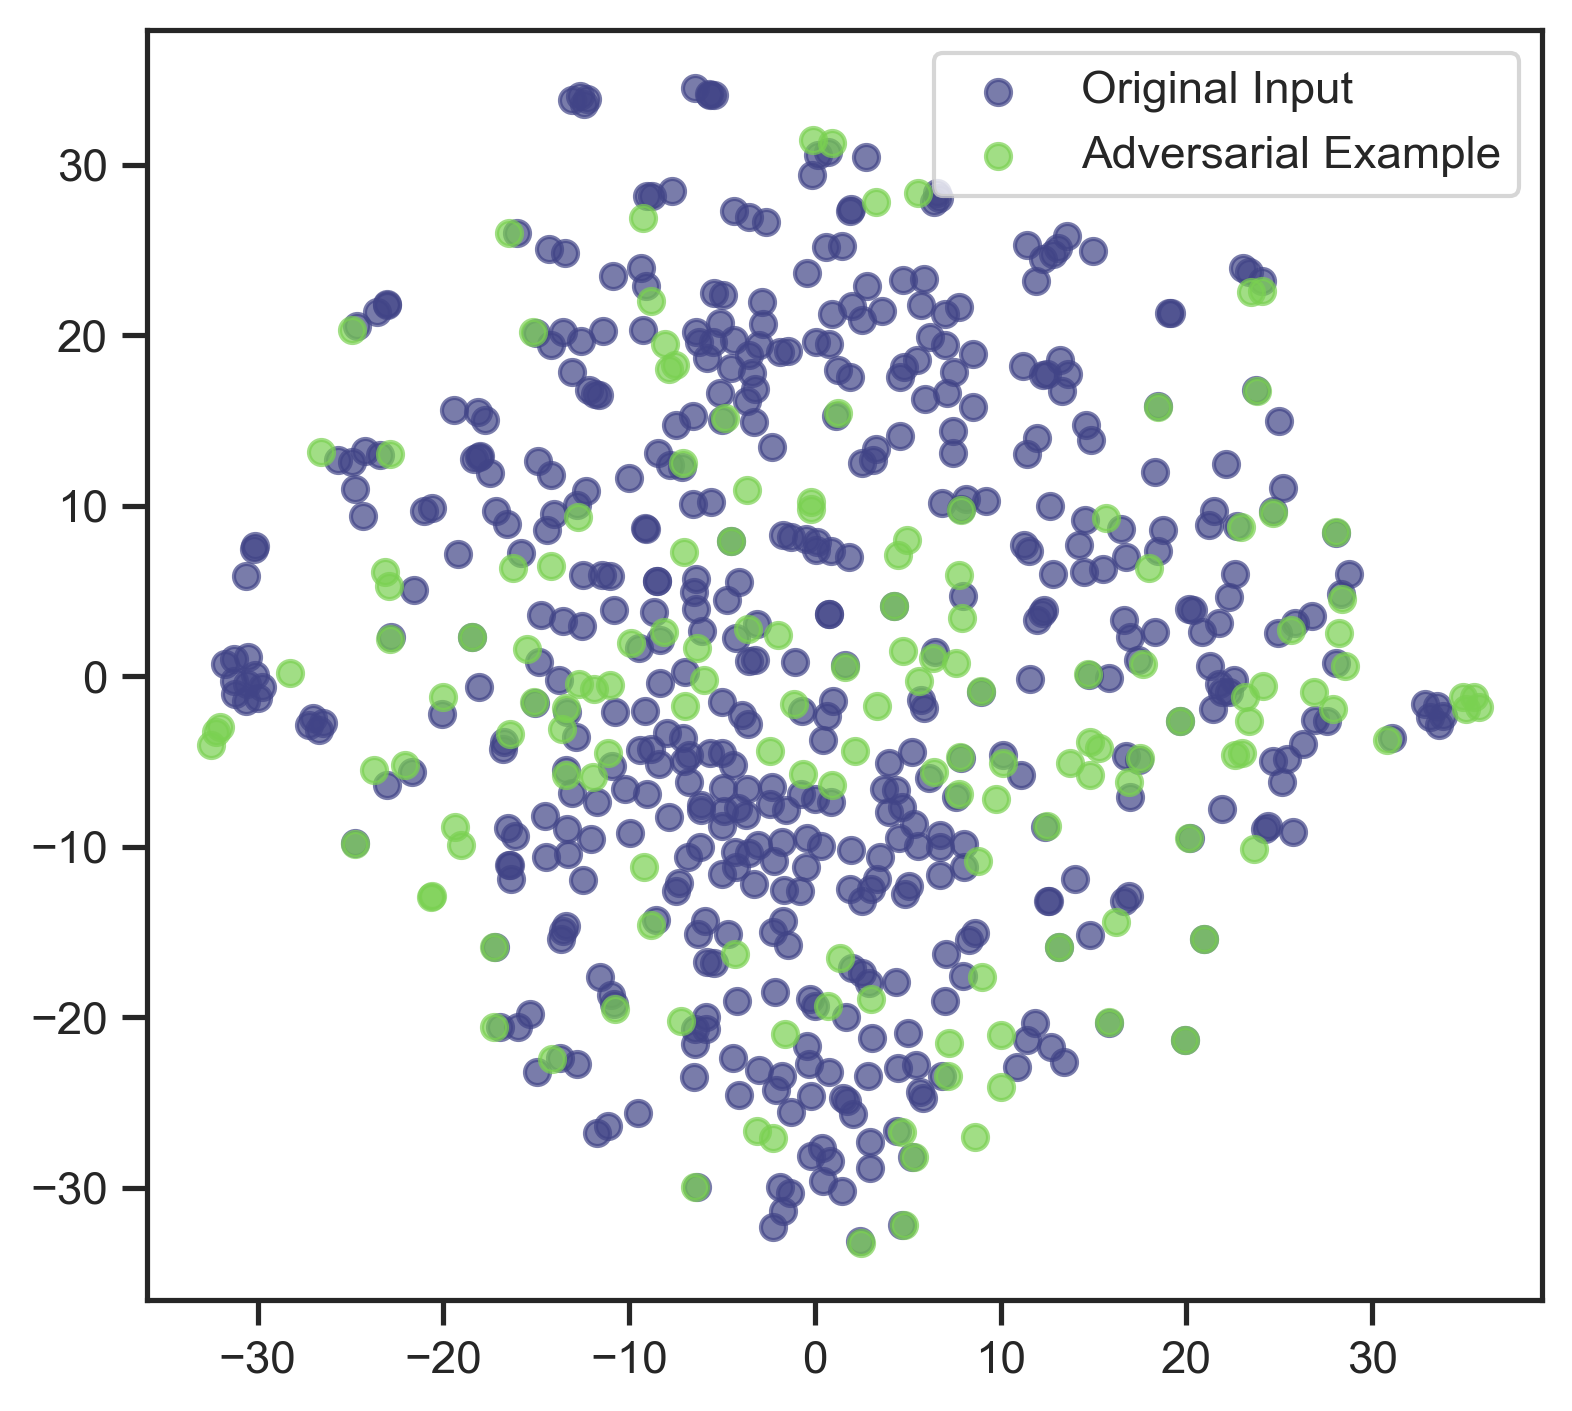

In [16]:
# PenDigits-TabTransformer
data_name = 'phishing_url'
model_name = 'MLP'
params = {'_lambda': 1, 'optimizer': 'adam', 'lr': 0.1, 'max_iter': 300, 'sample_num': 500, 'kappa': 0}
# npy 500 files and store into one ndarray
datapoints = load_datapoints(params= params, 
                            dataset= data_name, 
                            model = model_name, 
                            attack = "baseline", 
                            folder="adversarial_examples")

original_instances, original_latent_vectors, latent_vectors, adversarial_examples, attack_success = datapoints
# random select 100 samples in latent_vectors[attack_success]
np.random.seed(42)
random_indices = np.random.choice(np.where(attack_success)[0], 150, replace=False)
latent_vectors_100 = latent_vectors[random_indices]
func_to_vis(original_latent_vectors, latent_vectors_100)

/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_35705/2792655443.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')
/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_35705/2792655443.py:43: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(z[indices, 0], z[indices, 1], c=colors[i], label=label, alpha=0.7)


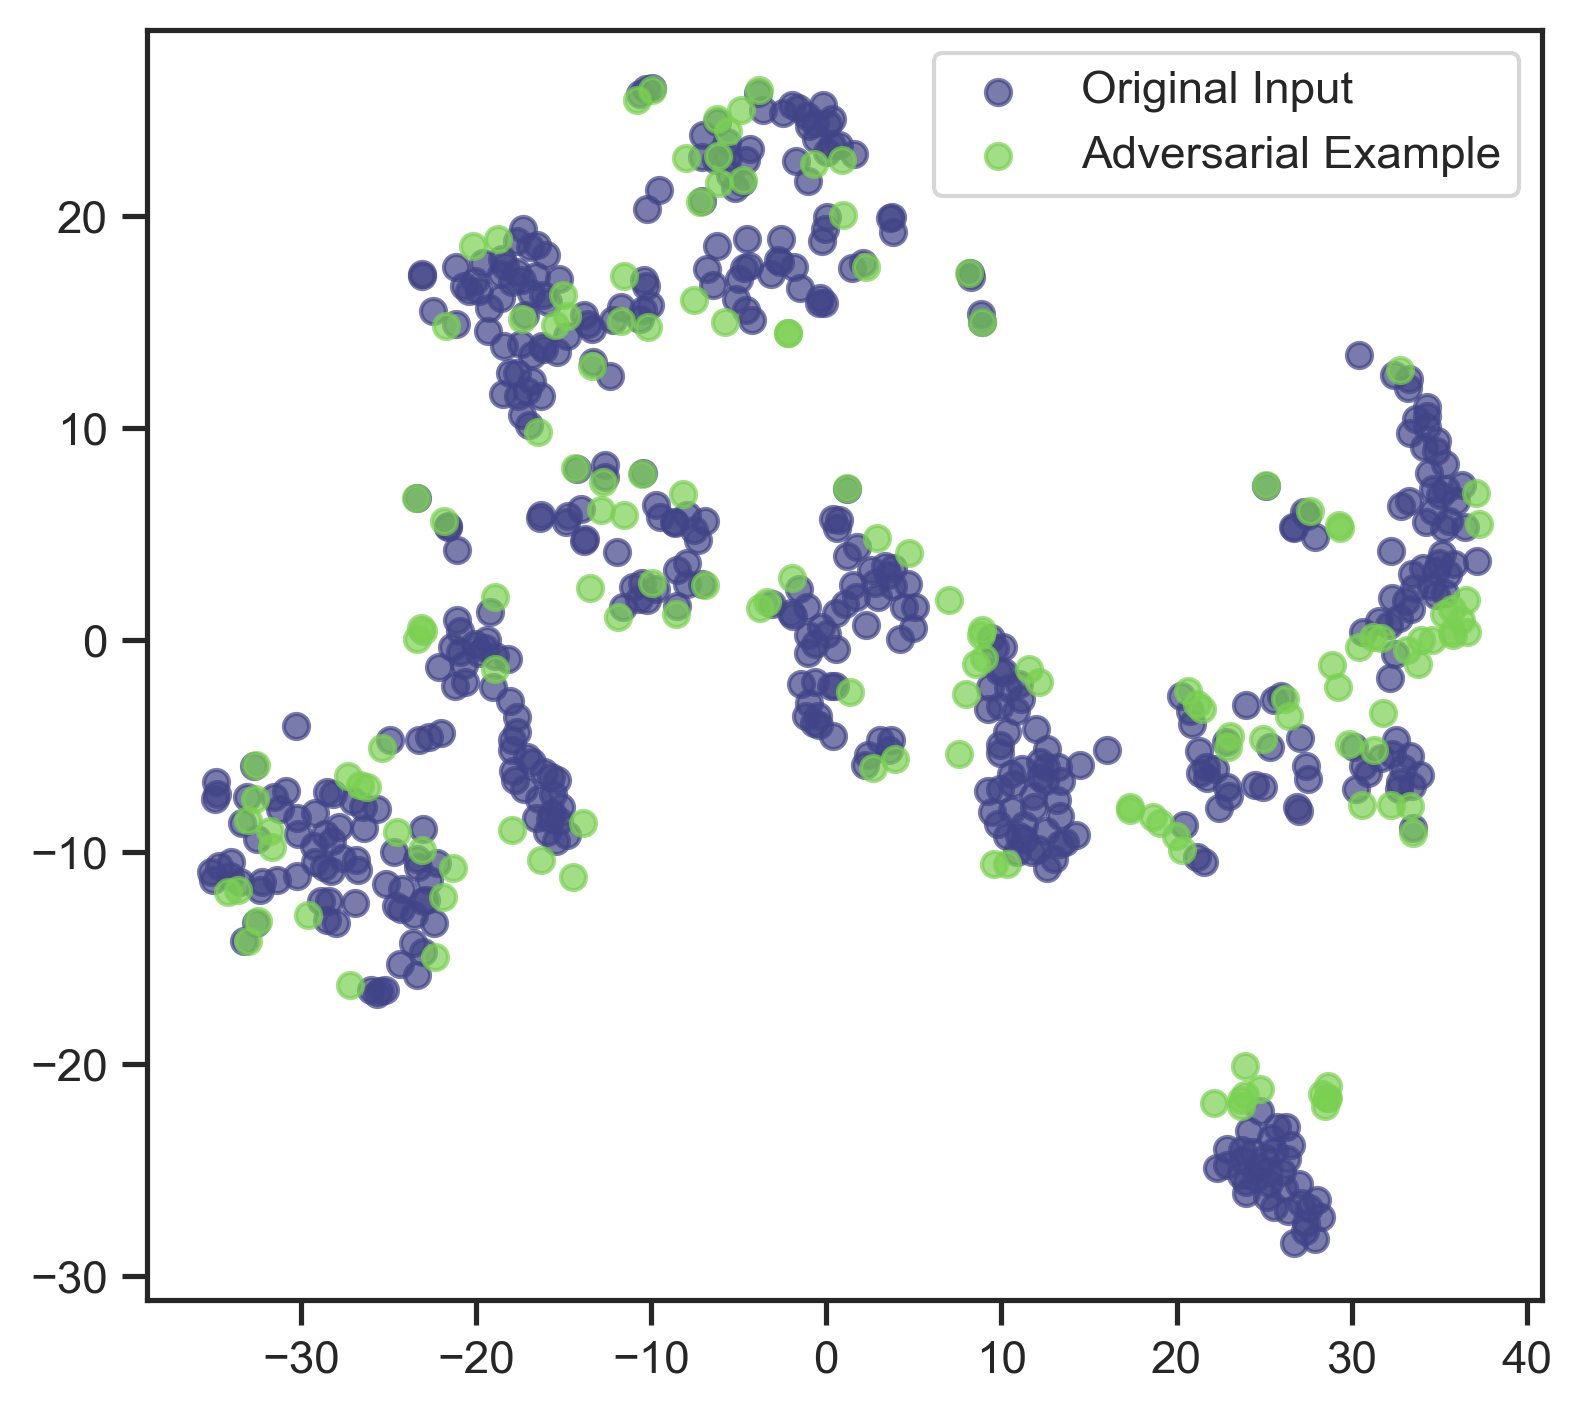

In [17]:
# PenDigits-TabTransformer
data_name = 'pendigit'
model_name = 'TabTransformer'
params = {'_lambda': 1, 'optimizer': 'adam', 'lr': 0.1, 'max_iter': 300, 'sample_num': 500, 'kappa': 0}
# npy 500 files and store into one ndarray
datapoints = load_datapoints(params= params, 
                                          dataset= data_name, 
                                          model = model_name, 
                                          attack = "baseline", 
                                          folder="adversarial_examples")

original_instances, original_latent_vectors, latent_vectors, adversarial_examples, attack_success = datapoints
# random select 100 samples in latent_vectors[attack_success]
np.random.seed(42)
random_indices = np.random.choice(np.where(attack_success)[0], 150, replace=False)
latent_vectors_100 = latent_vectors[random_indices]
func_to_vis(original_latent_vectors, latent_vectors_100)

### Baseline 3: Black Box Attack with confidence re-ranking

### Baseline 4: PGD Attacks

In [ ]:
parameter_grid_baseline = {
    'epsilon': [0.5],
    'alpha': [0.05],
    'num_steps': [50],
    'sample_num': [500],
}

dataset_list = ['adult', 'phishing_url', 'pendigit']
model_list = ['MLP', 'SoftDecisionTree', 'TabTransformer']

folder_path = 'results'
attack_name = 'pgd'
sample_times = 500
file_name = 'overall_results.json'



### Baseline 6: independent attacks